# MovieLens 推荐系统实验报告

这个 Notebook 用于展示数据分析、实验设置、模型效果对比和推荐案例。建议先运行训练脚本生成 `artifacts/` 再执行本报告。

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

movies = pd.read_csv(DATA_DIR / 'movies.csv')
ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
tags = pd.read_csv(DATA_DIR / 'tags.csv')

metrics_path = ARTIFACTS_DIR / 'metrics_summary.json'
metrics = pd.DataFrame(json.loads(metrics_path.read_text(encoding='utf-8'))) if metrics_path.exists() else pd.DataFrame()
metrics

,model,users_evaluated,hit_rate@10,hit_rate@20,recall@10,recall@20,ndcg@10,ndcg@20,map@10,mrr,item_coverage@10
0,lightfm,4635,0.099461,0.163323,0.099461,0.163323,0.050288,0.066230,0.035506,0.048271,0.549328
1,svd,4635,0.096656,0.161597,0.096656,0.161597,0.048985,0.065316,0.034730,0.046892,0.286372
2,usercf,4635,0.087810,0.146063,0.087810,0.146063,0.044755,0.059449,0.031865,0.043669,0.140883
3,two_stage,4635,0.088457,0.143258,0.088457,0.143258,0.044361,0.058115,0.031204,0.040851,0.274472
4,als,4635,0.090183,0.155124,0.090183,0.155124,0.043975,0.060184,0.030221,0.043096,0.560461
5,itemcf,4635,0.084358,0.132686,0.084358,0.132686,0.043970,0.056125,0.031872,0.042229,0.185413
6,bpr,4635,0.058252,0.104639,0.058252,0.104639,0.029356,0.041072,0.020660,0.031072,0.654511
7,popularity,4635,0.051996,0.090831,0.051996,0.090831,0.025900,0.035613,0.018121,0.025598,0.034549
8,content,4635,0.031931,0.056311,0.031931,0.056311,0.015655,0.021781,0.010785,0.016447,0.489827


## 数据集概览

In [2]:
dataset_summary = pd.DataFrame([
    {'metric': 'users', 'value': ratings['userId'].nunique()},
    {'metric': 'movies', 'value': movies['movieId'].nunique()},
    {'metric': 'ratings', 'value': len(ratings)},
    {'metric': 'tags', 'value': len(tags)},
    {'metric': 'sparsity', 'value': 1 - len(ratings) / (ratings['userId'].nunique() * movies['movieId'].nunique())},
])
dataset_summary

,metric,value
0,users,1.384930e+05
1,movies,2.727800e+04
2,ratings,2.000026e+07
3,tags,4.655640e+05
4,sparsity,9.947059e-01


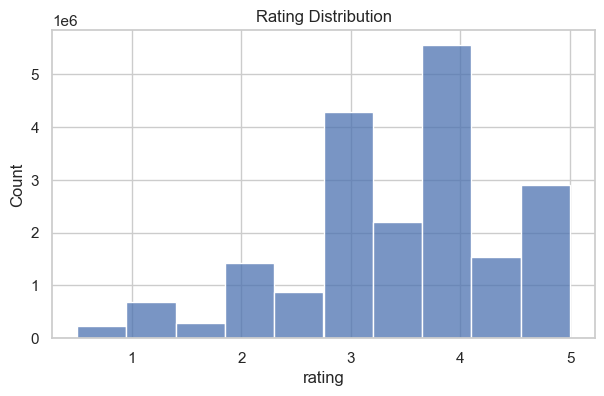

In [3]:
plt.figure(figsize=(7, 4))
sns.histplot(ratings['rating'], bins=10)
plt.title('Rating Distribution')
plt.show()

## 热门电影与热门类型

In [4]:
top_movies = ratings.groupby('movieId').size().sort_values(ascending=False).head(10).rename('rating_count').reset_index()
top_movies = top_movies.merge(movies[['movieId', 'title', 'genres']], on='movieId', how='left')
top_movies

,movieId,rating_count,title,genres
0,296,67310,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,356,66172,Forrest Gump (1994),Comedy|Drama|Romance|War
2,318,63366,"Shawshank Redemption, The (1994)",Crime|Drama
3,593,63299,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,480,59715,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
5,260,54502,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,110,53769,Braveheart (1995),Action|Drama|War
7,589,52244,Terminator 2: Judgment Day (1991),Action|Sci-Fi
8,2571,51334,"Matrix, The (1999)",Action|Sci-Fi|Thriller
9,527,50054,Schindler's List (1993),Drama|War


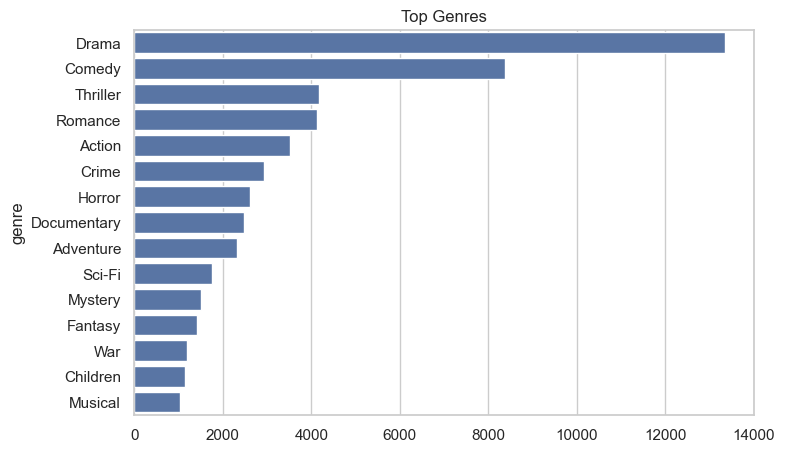

In [5]:
genre_counts = (
    movies.assign(genre=movies['genres'].fillna('').str.split('|'))
    .explode('genre')
    .query("genre != '(no genres listed)'")
    .groupby('genre')
    .size()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(8, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Top Genres')
plt.show()

## 模型对比实验

In [6]:
if metrics.empty:
    print('请先运行训练脚本生成 artifacts/metrics_summary.json')
else:
    display(metrics)

,model,users_evaluated,hit_rate@10,hit_rate@20,recall@10,recall@20,ndcg@10,ndcg@20,map@10,mrr,item_coverage@10
0,lightfm,4635,0.099461,0.163323,0.099461,0.163323,0.050288,0.066230,0.035506,0.048271,0.549328
1,svd,4635,0.096656,0.161597,0.096656,0.161597,0.048985,0.065316,0.034730,0.046892,0.286372
2,usercf,4635,0.087810,0.146063,0.087810,0.146063,0.044755,0.059449,0.031865,0.043669,0.140883
3,two_stage,4635,0.088457,0.143258,0.088457,0.143258,0.044361,0.058115,0.031204,0.040851,0.274472
4,als,4635,0.090183,0.155124,0.090183,0.155124,0.043975,0.060184,0.030221,0.043096,0.560461
5,itemcf,4635,0.084358,0.132686,0.084358,0.132686,0.043970,0.056125,0.031872,0.042229,0.185413
6,bpr,4635,0.058252,0.104639,0.058252,0.104639,0.029356,0.041072,0.020660,0.031072,0.654511
7,popularity,4635,0.051996,0.090831,0.051996,0.090831,0.025900,0.035613,0.018121,0.025598,0.034549
8,content,4635,0.031931,0.056311,0.031931,0.056311,0.015655,0.021781,0.010785,0.016447,0.489827


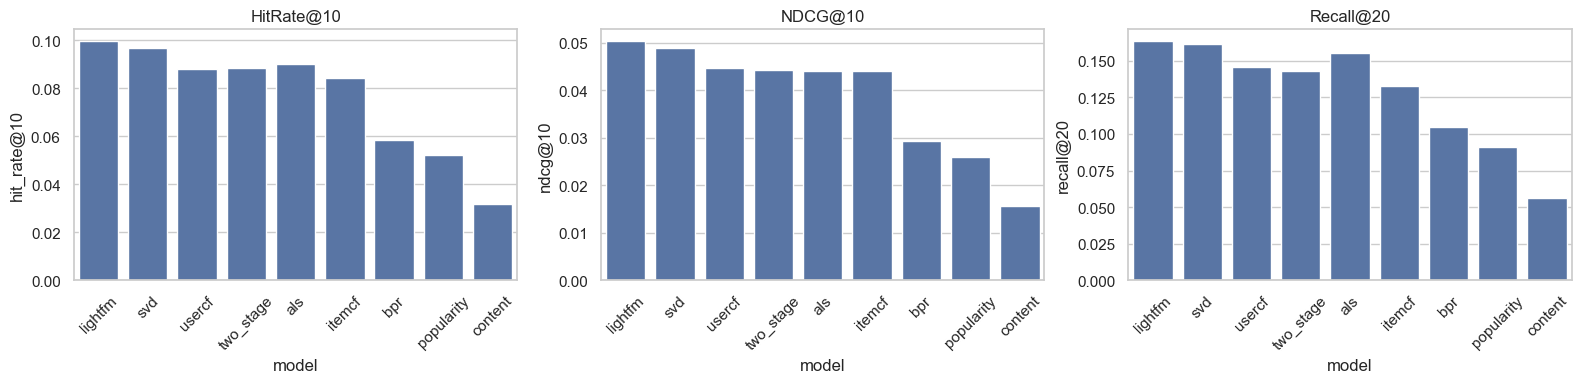

In [7]:
if not metrics.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.barplot(data=metrics, x='model', y='hit_rate@10', ax=axes[0])
    axes[0].set_title('HitRate@10')
    axes[0].tick_params(axis='x', rotation=45)

    sns.barplot(data=metrics, x='model', y='ndcg@10', ax=axes[1])
    axes[1].set_title('NDCG@10')
    axes[1].tick_params(axis='x', rotation=45)

    sns.barplot(data=metrics, x='model', y='recall@20', ax=axes[2])
    axes[2].set_title('Recall@20')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

## 推荐案例分析

In [8]:
manifest_path = ARTIFACTS_DIR / 'manifest.json'
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
    display(pd.DataFrame(manifest.get('models', {})).T[['status']])
else:
    print('manifest.json 不存在，请先训练模型。')

,status
popularity,trained
content,trained
usercf,trained
itemcf,trained
svd,trained
two_stage,trained
als,trained
bpr,trained
lightfm,trained


## 总结

- 对比不同模型在同一 Leave-One-Out 协议下的离线指标。
- 分析内容特征是否给推荐效果带来提升。
- 结合推荐案例总结每类模型的优势与局限。